[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/workshops/workshop-05-arbol-decision-california-housing.ipynb)

# Taller Express: Regresión con Árboles de Decisión en Google Colab

**Universidad El Bosque**  

**Curso:** Aprendizaje Supervisado Avanzado

**Autor:** Juan Sebastian Laverde Chunza

## Objetivo

Entrenar, ajustar e interpretar un **Árbol de Decisión para regresión** sobre el conjunto de datos **California Housing**, observando el efecto de la profundidad del árbol sobre el sobreajuste y el desempeño del modelo.

También se realizarán **predicciones puntuales**.

> Este notebook se limita a las herramientas indicadas en el taller: **Python, scikit-learn, pandas y matplotlib**.

## Variables indicadas en el taller

- `MedInc`: ingreso medio del bloque
- `HouseAge`: edad media de las viviendas
- `AveRooms`: promedio de habitaciones
- `AveBedrms`: promedio de dormitorios
- `Population`: población del bloque
- `AveOccup`: ocupantes promedio
- `Latitude`: latitud
- `Longitude`: longitud
- `MedHouseVal`: valor medio de la vivienda, variable objetivo

## 1. Importar las herramientas del taller

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

## 2. Cargar el conjunto de datos

Se utiliza exactamente la URL suministrada en el taller.

In [2]:
url = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/housing.csv"
df = pd.read_csv(url)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print("Número de filas y columnas:", df.shape)
print("\nColumnas disponibles:")
print(df.columns.tolist())

Número de filas y columnas: (20640, 10)

Columnas disponibles:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


## 3. Organizar las variables indicadas en el taller

La URL del taller contiene las variables en formato crudo. Para trabajar con los nombres que aparecen en el enunciado:

- `AveRooms` se obtiene como habitaciones totales / hogares.
- `AveBedrms` se obtiene como dormitorios totales / hogares.
- `AveOccup` se obtiene como población / hogares.
- Las demás variables se toman directamente de las columnas correspondientes.

No se incorpora ninguna variable adicional.

In [4]:
datos = pd.DataFrame({
    "MedInc": df["median_income"],
    "HouseAge": df["housing_median_age"],
    "AveRooms": df["total_rooms"] / df["households"],
    "AveBedrms": df["total_bedrooms"] / df["households"],
    "Population": df["population"],
    "AveOccup": df["population"] / df["households"],
    "Latitude": df["latitude"],
    "Longitude": df["longitude"],
    "MedHouseVal": df["median_house_value"]
})

# Se eliminan únicamente las filas con datos faltantes para poder entrenar el árbol.
datos = datos.dropna()

print("Dimensiones de los datos utilizados:", datos.shape)
datos.head()

Dimensiones de los datos utilizados: (20433, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


# 4. Análisis Exploratorio de Datos (EDA)

El objetivo del EDA es conocer los datos antes de entrenar el modelo. Se revisan:

1. Dimensiones y estructura.
2. Tipos de datos.
3. Valores faltantes.
4. Estadísticos descriptivos.
5. Distribución de las variables.
6. Relación entre las variables predictoras y `MedHouseVal`.
7. Correlaciones entre las variables numéricas.

## 4.1 Dimensiones y primeras observaciones

In [6]:
print("Número de observaciones:", datos.shape[0])
print("Número de variables:", datos.shape[1])

datos.head()

Número de observaciones: 20433
Número de variables: 9


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


## 4.2 Tipos de datos

Como el taller trabaja con variables numéricas, se verifica que las columnas utilizadas tengan ese tipo de información.

In [7]:
datos.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


## 4.3 Información general del conjunto de datos

In [8]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20433 non-null  float64
 1   HouseAge     20433 non-null  float64
 2   AveRooms     20433 non-null  float64
 3   AveBedrms    20433 non-null  float64
 4   Population   20433 non-null  float64
 5   AveOccup     20433 non-null  float64
 6   Latitude     20433 non-null  float64
 7   Longitude    20433 non-null  float64
 8   MedHouseVal  20433 non-null  float64
dtypes: float64(9)
memory usage: 1.6 MB


## 4.4 Valores faltantes

Se revisa cuántos valores faltantes existen en cada variable.

In [9]:
faltantes = datos.isnull().sum()

faltantes

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


No hay datos faltantes, por ende, no se utiliza ningún método de imputación.

### Visualización de datos faltantes

Además del conteo numérico, se realiza una comprobación visual de los datos faltantes.

Primero se muestra la **proporción de datos faltantes por variable**. Después se presenta un **mapa de presencia/ausencia de datos**, donde cada fila corresponde a una observación y cada columna a una variable.

En este conjunto de datos se espera observar una proporción de faltantes igual a **0** en todas las variables.

#### Mapa visual de datos faltantes

El siguiente gráfico representa visualmente la presencia o ausencia de información en cada variable. Si existieran valores faltantes, aparecerían zonas diferentes dentro de la matriz.

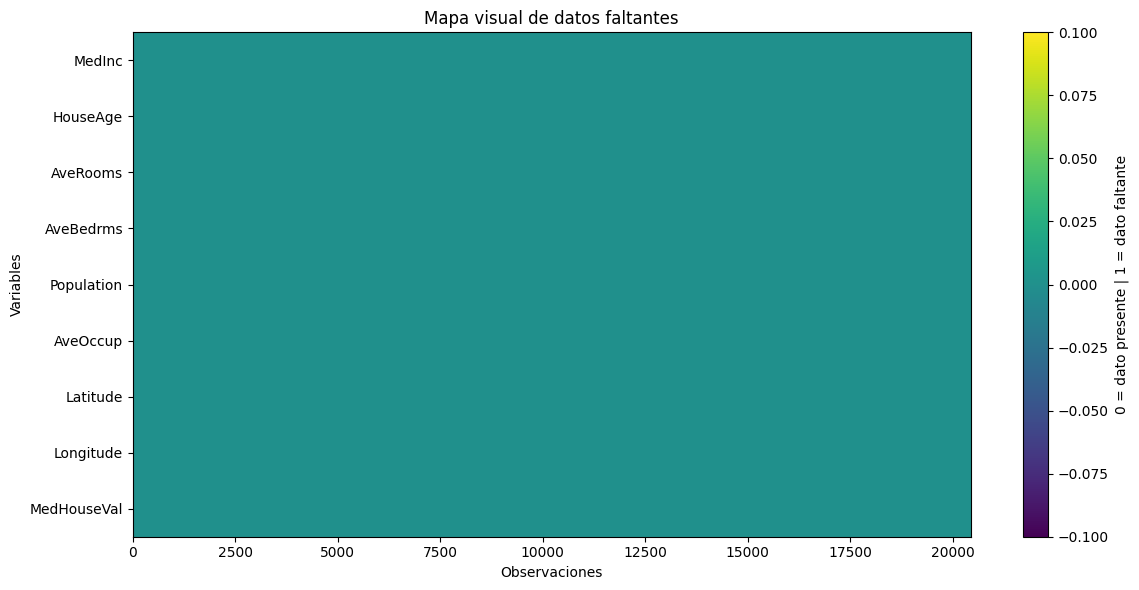

In [10]:
mapa_faltantes = datos.isnull().astype(int)

plt.figure(figsize=(12, 6))
plt.imshow(mapa_faltantes.T, aspect="auto")
plt.yticks(
    range(len(mapa_faltantes.columns)),
    mapa_faltantes.columns
)
plt.xlabel("Observaciones")
plt.ylabel("Variables")
plt.title("Mapa visual de datos faltantes")
plt.colorbar(label="0 = dato presente | 1 = dato faltante")
plt.tight_layout()
plt.show()

## 4.5 Estadísticos descriptivos

Se observan medidas como media, desviación estándar, mínimo, máximo y cuartiles de cada variable.

In [11]:
datos.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,3.871162,28.633094,5.431344,1.097062,1424.946949,3.071533,35.633221,-119.570689,206864.413155
std,1.899291,12.591805,2.482946,0.476104,1133.208490,10.438269,2.136348,2.003578,115435.667099
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,14999.000000
25%,2.563700,18.000000,4.441441,1.006029,787.000000,2.429032,33.930000,-121.800000,119500.000000
50%,3.536500,29.000000,5.230769,1.048889,1166.000000,2.817582,34.260000,-118.490000,179700.000000
75%,4.744000,37.000000,6.052381,1.099631,1722.000000,3.281513,37.720000,-118.010000,264700.000000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,500001.000000


## 4.6 Distribución de las variables

Los histogramas permiten observar cómo se distribuyen las ocho variables predictoras y la variable objetivo.

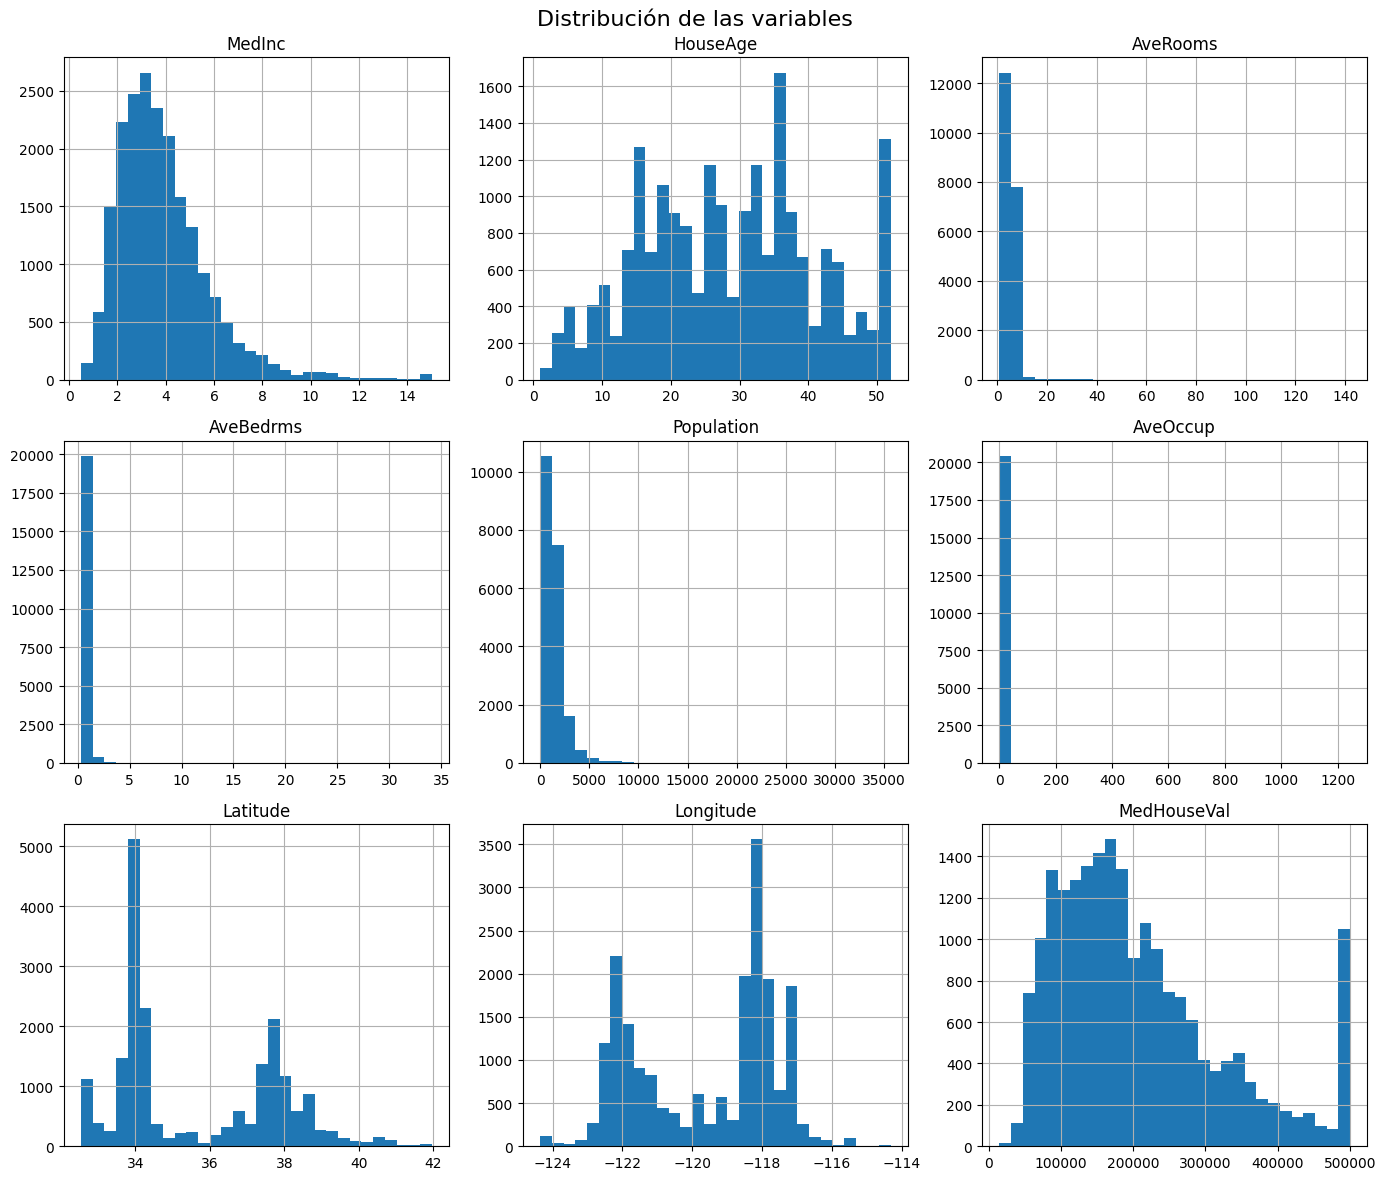

In [12]:
datos.hist(figsize=(14, 12), bins=30)
plt.suptitle("Distribución de las variables", fontsize=16)
plt.tight_layout()
plt.show()

### Distribución de la variable objetivo

Se observa de forma individual la distribución de `MedHouseVal`, que es la variable que el árbol debe predecir.

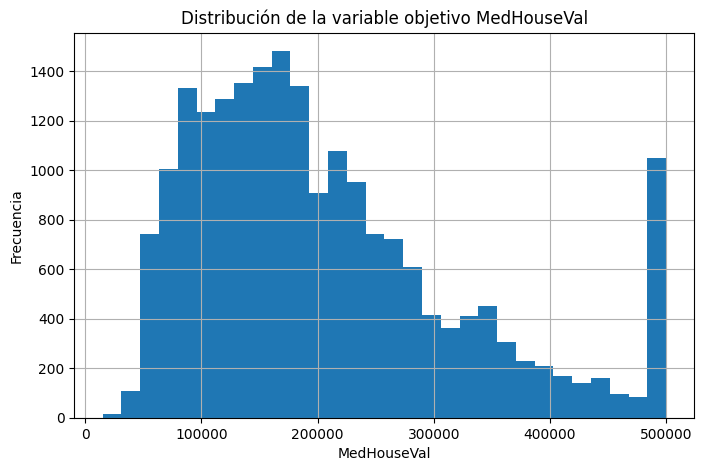

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(datos["MedHouseVal"], bins=30)
plt.xlabel("MedHouseVal")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo MedHouseVal")
plt.grid(True)
plt.show()

## 4.7 Relación entre las predictoras y la variable objetivo

Se construyen gráficos de dispersión para observar visualmente la relación entre cada variable predictora y `MedHouseVal`.

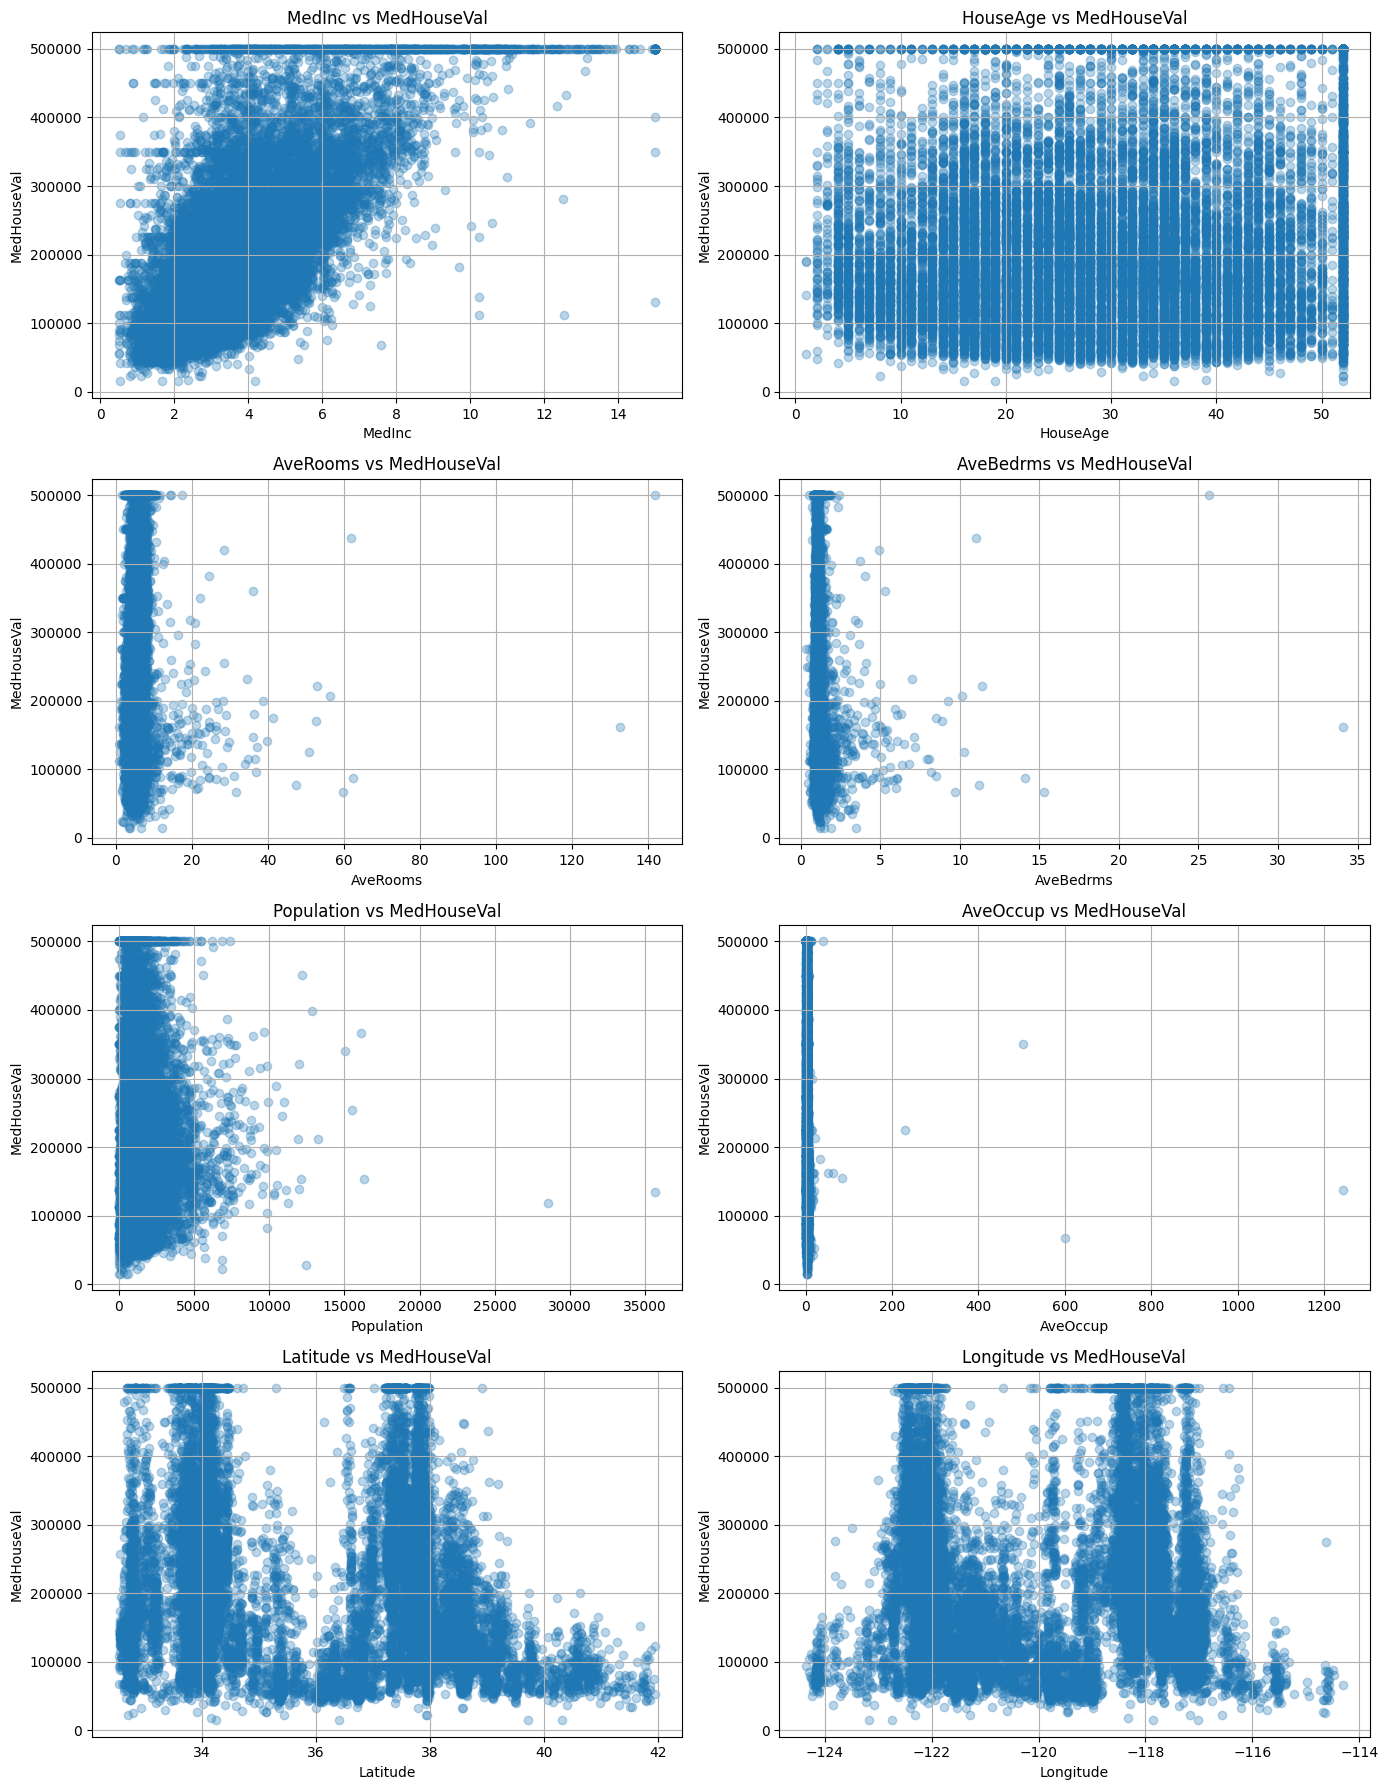

In [14]:
variables_predictoras = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for variable, ax in zip(variables_predictoras, axes.flatten()):
    ax.scatter(datos[variable], datos["MedHouseVal"], alpha=0.3)
    ax.set_xlabel(variable)
    ax.set_ylabel("MedHouseVal")
    ax.set_title(f"{variable} vs MedHouseVal")
    ax.grid(True)

plt.tight_layout()
plt.show()

## 4.8 Matriz de correlación

La correlación permite observar la intensidad y dirección de la relación lineal entre las variables numéricas. Se calcula directamente con `pandas`.

In [15]:
correlacion = datos.corr(numeric_only=True)

correlacion

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.118278,0.325307,-0.062299,0.005087,0.018894,-0.079626,-0.015550,0.688355
HouseAge,-0.118278,1.000000,-0.153031,-0.077918,-0.295787,0.013258,0.011899,-0.109357,0.106432
AveRooms,0.325307,-0.153031,1.000000,0.848616,-0.071898,-0.004873,0.106423,-0.027307,0.151344
AveBedrms,-0.062299,-0.077918,0.848616,1.000000,-0.066510,-0.006179,0.070025,0.013402,-0.046739
Population,0.005087,-0.295787,-0.071898,-0.066510,1.000000,0.070062,-0.108997,0.100270,-0.025300
AveOccup,0.018894,0.013258,-0.004873,-0.006179,0.070062,1.000000,0.002522,0.002304,-0.023639
Latitude,-0.079626,0.011899,0.106423,0.070025,-0.108997,0.002522,1.000000,-0.924616,-0.144638
Longitude,-0.015550,-0.109357,-0.027307,0.013402,0.100270,0.002304,-0.924616,1.000000,-0.045398
MedHouseVal,0.688355,0.106432,0.151344,-0.046739,-0.025300,-0.023639,-0.144638,-0.045398,1.000000


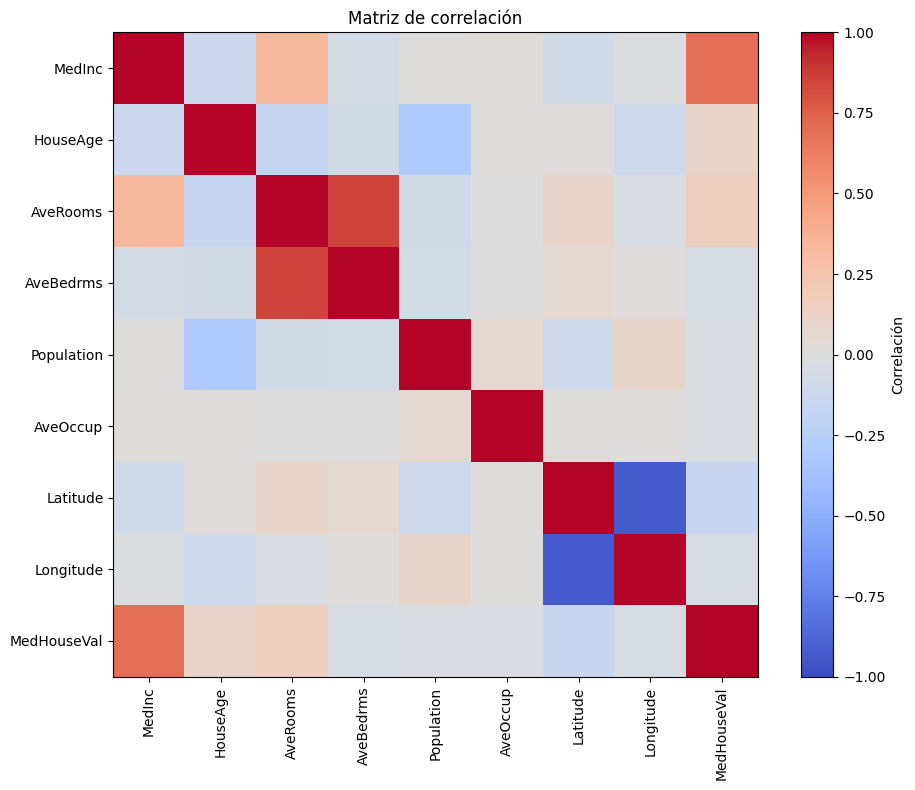

In [16]:
plt.figure(figsize=(10, 8))

imagen = plt.imshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.colorbar(imagen, label="Correlación")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Correlación con la variable objetivo

Se ordenan las correlaciones con `MedHouseVal` para identificar cuáles variables muestran una relación lineal más alta o más baja con el valor medio de la vivienda.

In [17]:
correlacion_objetivo = correlacion["MedHouseVal"].sort_values(ascending=False)

correlacion_objetivo

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688355
AveRooms,0.151344
HouseAge,0.106432
AveOccup,-0.023639
Population,-0.025300
Longitude,-0.045398
AveBedrms,-0.046739
Latitude,-0.144638


### Conclusión del EDA

El análisis exploratorio permite conocer la estructura de los datos, detectar valores faltantes, revisar los rangos de las variables y observar sus distribuciones y relaciones con `MedHouseVal`.

Este análisis sirve como paso previo al entrenamiento del Árbol de Decisión, pero no modifica las ocho variables predictoras definidas en el taller.

# 5. Separar variables predictoras y variable objetivo

In [18]:
datos

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,78100.0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,77100.0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,92300.0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,84700.0


In [19]:
X = datos.iloc[:, 0:8].values
y = datos.iloc[:, 8].values

In [20]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [21]:
y

array([452600., 358500., 352100., ...,  92300.,  84700.,  89400.])

Para garantizar que me este tomando las variables

In [22]:
print(datos.columns[0:8])


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [23]:
print(datos.columns[8])

MedHouseVal


# 6. Separar datos de entrenamiento y prueba

Esta separación permite comparar el desempeño del árbol con datos usados para entrenar y con datos que el modelo no utilizó durante el entrenamiento.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (14303, 8)
Prueba: (6130, 8)


In [25]:
X_train

array([[   5.7578    ,   20.        ,    6.63036649, ...,    2.79371728,
          36.58      , -121.86      ],
       [   5.1785    ,   17.        ,    6.16557734, ...,    2.98474946,
          33.84      , -117.85      ],
       [   4.2989    ,   34.        ,    4.7876588 , ...,    2.08711434,
          34.16      , -118.4       ],
       ...,
       [   4.0337    ,   23.        ,    6.0944206 , ...,    3.40343348,
          38.16      , -122.26      ],
       [   3.375     ,    9.        ,    3.18181818, ...,    7.61818182,
          33.74      , -117.86      ],
       [   1.4828    ,   24.        ,    4.24832215, ...,    3.63422819,
          32.67      , -115.49      ]])

In [26]:
X_test

array([[   2.875     ,   37.        ,    5.80266667, ...,    3.46933333,
          32.7       , -117.08      ],
       [   3.525     ,   20.        ,    4.42917251, ...,    3.36044881,
          34.11      , -117.91      ],
       [   1.3448    ,   11.        ,    3.36568214, ...,    2.67932489,
          32.75      , -117.1       ],
       ...,
       [   2.178     ,   17.        ,    5.11130137, ...,    2.64383562,
          40.59      , -124.14      ],
       [   1.2617    ,   15.        ,    5.31182796, ...,    3.79569892,
          35.36      , -118.98      ],
       [   2.6083    ,   52.        ,    3.74618321, ...,    3.10687023,
          37.77      , -122.41      ]])

In [27]:
y_train

array([347700., 247300., 364700., ..., 130400., 165300.,  73100.])

In [28]:
y_test

array([ 98900., 153000.,  91300., ...,  76800.,  42700., 193800.])

## APLICAR LOS ARBOLES DE DECISION


In [29]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
regressor= DecisionTreeRegressor(random_state=0)
regressor.fit(X_train,y_train);

## Ahora se puede predecir

In [30]:
y_pred= regressor.predict(X_train)
y_pred

array([347700., 247300., 364700., ..., 130400., 165300.,  73100.])

In [31]:
X_train

array([[   5.7578    ,   20.        ,    6.63036649, ...,    2.79371728,
          36.58      , -121.86      ],
       [   5.1785    ,   17.        ,    6.16557734, ...,    2.98474946,
          33.84      , -117.85      ],
       [   4.2989    ,   34.        ,    4.7876588 , ...,    2.08711434,
          34.16      , -118.4       ],
       ...,
       [   4.0337    ,   23.        ,    6.0944206 , ...,    3.40343348,
          38.16      , -122.26      ],
       [   3.375     ,    9.        ,    3.18181818, ...,    7.61818182,
          33.74      , -117.86      ],
       [   1.4828    ,   24.        ,    4.24832215, ...,    3.63422819,
          32.67      , -115.49      ]])

In [32]:
y_train

array([347700., 247300., 364700., ..., 130400., 165300.,  73100.])

## Creación de la malla para la curva suave (Usando X original), Se utiliza los metodos, min ymax de numpy para evitar problemas de dimensionalidad

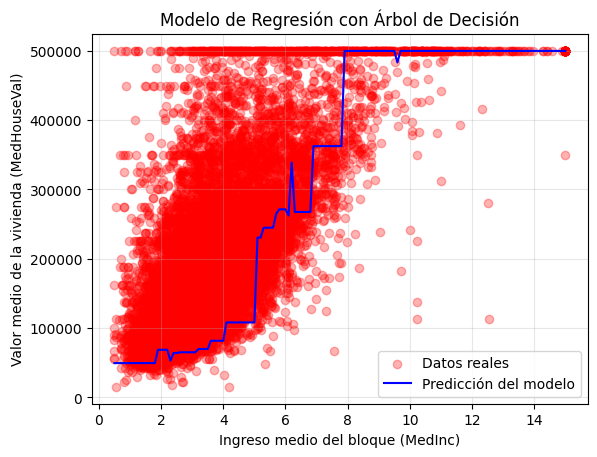

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Variable que queremos visualizar: MedInc (columna 0)
X_grid = np.arange(
    X_train[:, 0].min(),
    X_train[:, 0].max(),
    0.1
).reshape(-1, 1)

# Promedio de las 8 variables predictoras
X_promedio = np.mean(X_train, axis=0)

# Crear la matriz que necesita el modelo (8 columnas)
X_grid_completo = np.tile(X_promedio, (len(X_grid), 1))

# Reemplazar MedInc por los valores de la malla
X_grid_completo[:, 0] = X_grid[:, 0]

# Datos reales
plt.scatter(
    X_train[:, 0],
    y_train,
    color='red',
    label='Datos reales',
    alpha=0.3
)

# Predicción del árbol
plt.plot(
    X_grid[:, 0],
    regressor.predict(X_grid_completo),
    color='blue',
    label='Predicción del modelo'
)

plt.title('Modelo de Regresión con Árbol de Decisión')
plt.xlabel('Ingreso medio del bloque (MedInc)')
plt.ylabel('Valor medio de la vivienda (MedHouseVal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

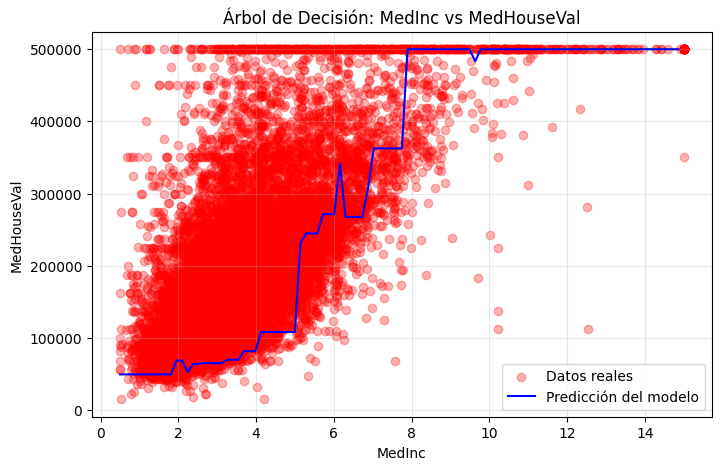

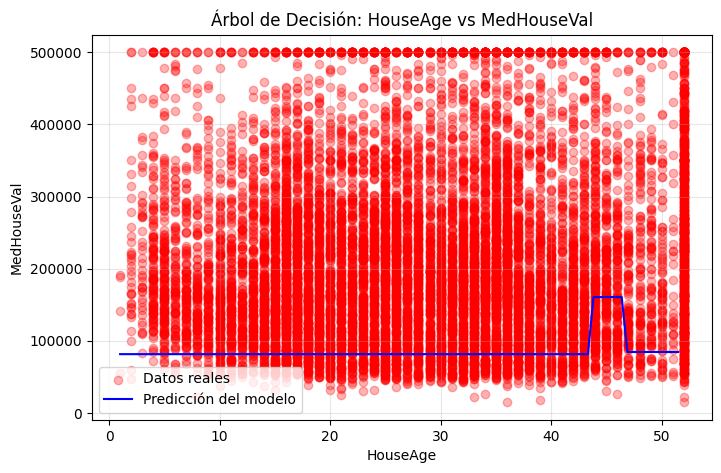

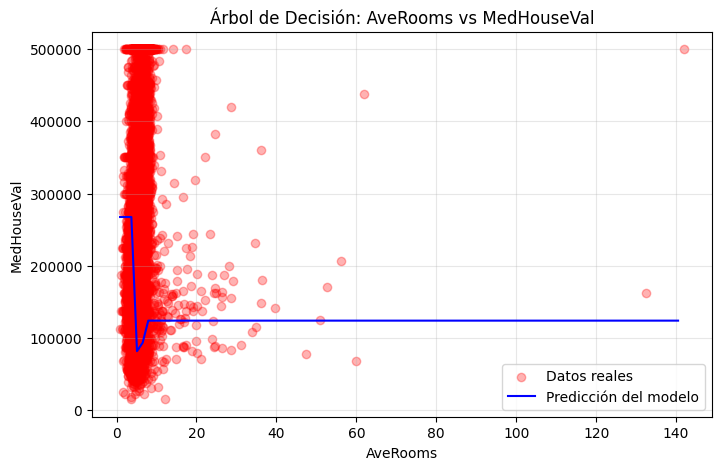

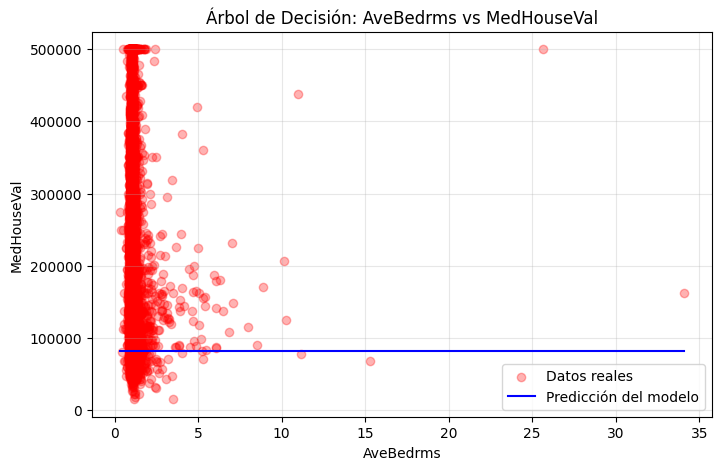

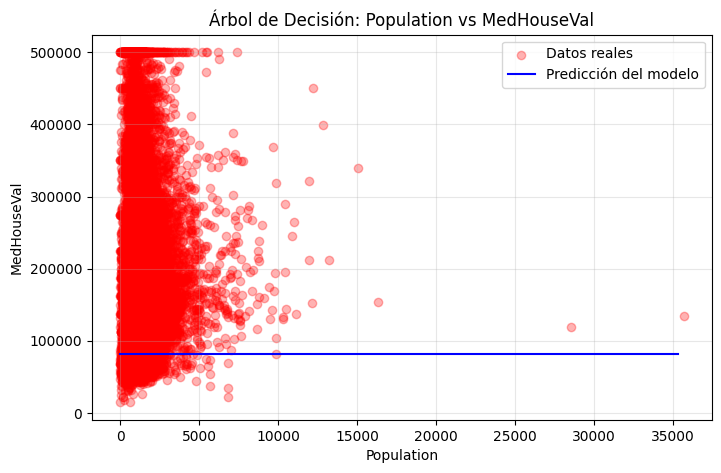

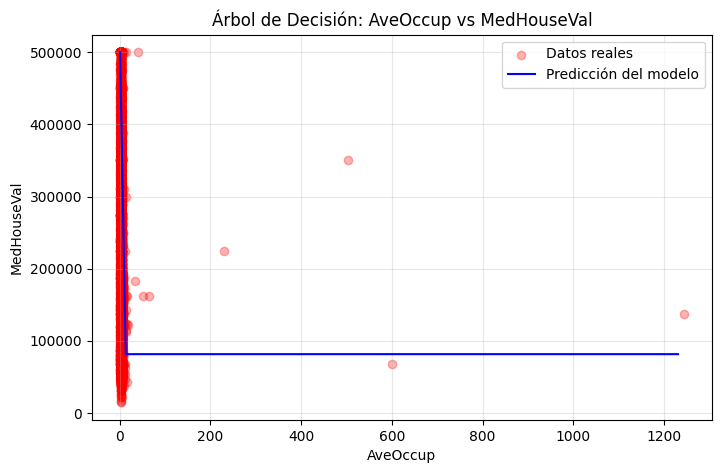

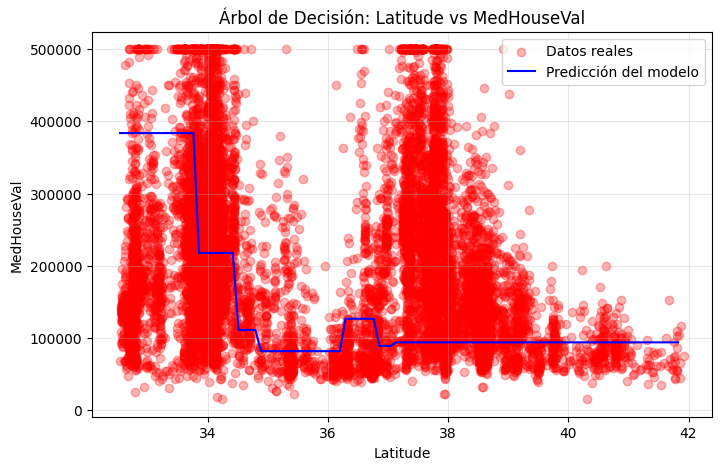

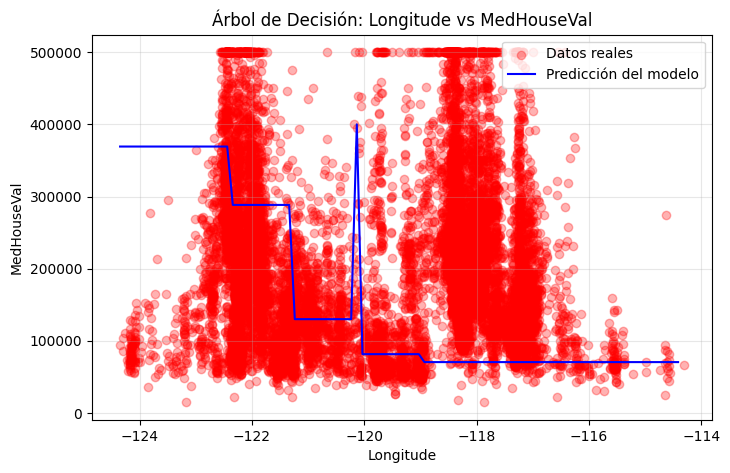

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Nombres de las 8 variables predictoras
variables = [
    'MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms',
    'Population',
    'AveOccup',
    'Latitude',
    'Longitude'
]

# Promedio de cada una de las 8 variables
X_promedio = np.mean(X_train, axis=0)

for i, variable in enumerate(variables):

    # Crear malla para la variable actual
    X_grid = np.arange(
        X_train[:, i].min(),
        X_train[:, i].max(),
        (X_train[:, i].max() - X_train[:, i].min()) / 100
    ).reshape(-1, 1)

    # Crear matriz con las 8 variables
    X_grid_completo = np.tile(
        X_promedio,
        (len(X_grid), 1)
    )

    # Variar únicamente la variable actual
    X_grid_completo[:, i] = X_grid[:, 0]

    # Crear gráfica
    plt.figure(figsize=(8, 5))

    plt.scatter(
        X_train[:, i],
        y_train,
        color='red',
        alpha=0.3,
        label='Datos reales'
    )

    plt.plot(
        X_grid[:, 0],
        regressor.predict(X_grid_completo),
        color='blue',
        label='Predicción del modelo'
    )

    plt.title(
        f'Árbol de Decisión: {variable} vs MedHouseVal'
    )

    plt.xlabel(variable)
    plt.ylabel('MedHouseVal')

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

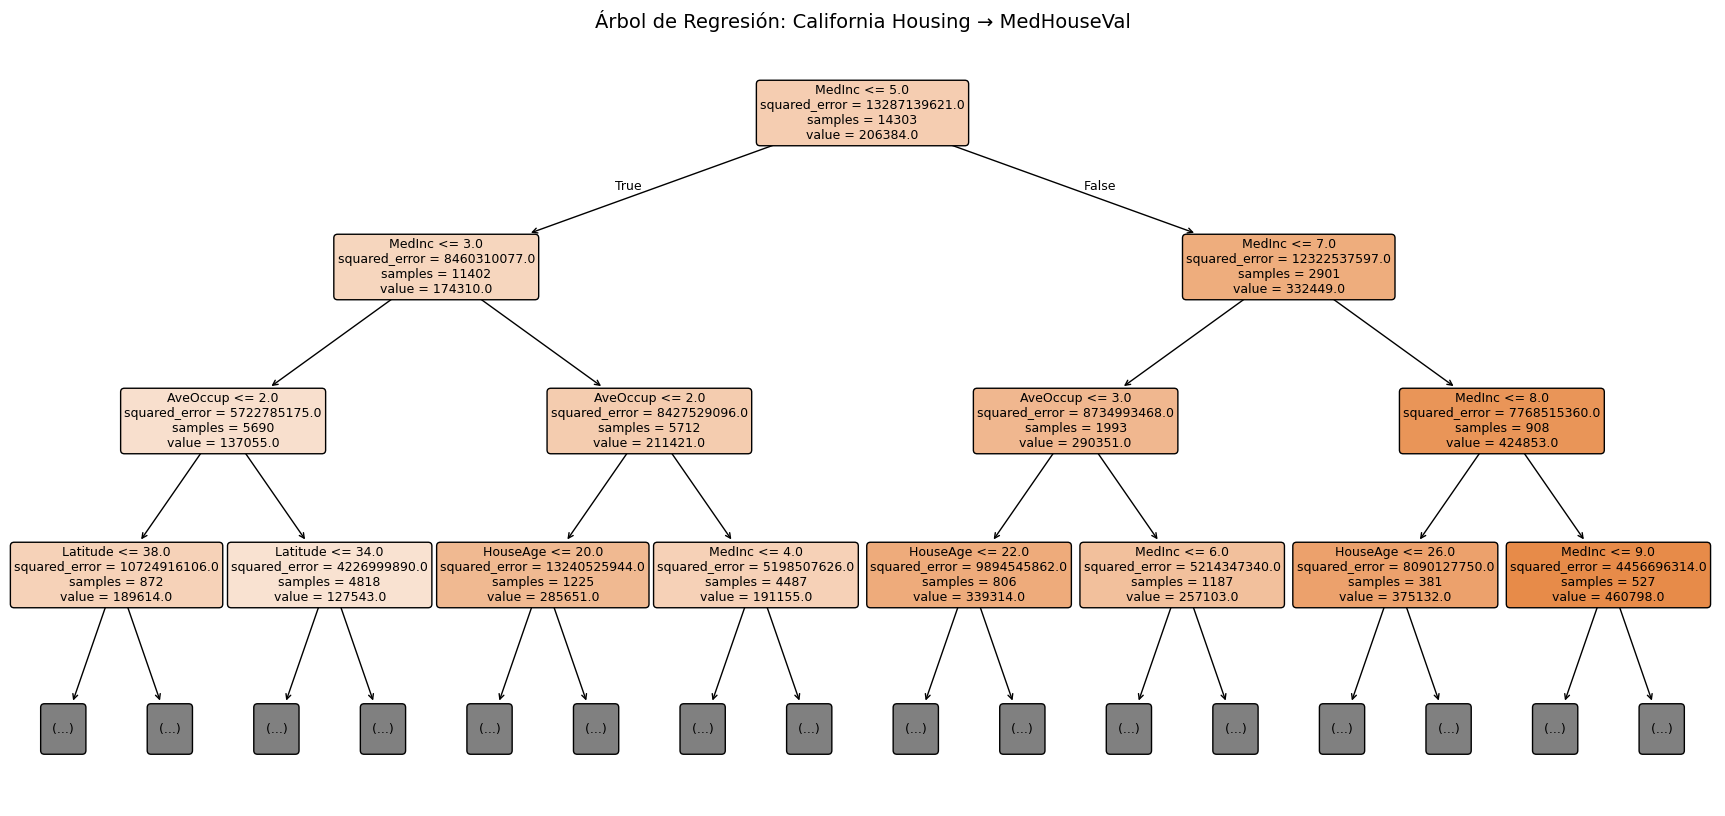

In [35]:
plt.figure(figsize=(22, 10))

plot_tree(
    regressor,

    feature_names=[
        'MedInc',
        'HouseAge',
        'AveRooms',
        'AveBedrms',
        'Population',
        'AveOccup',
        'Latitude',
        'Longitude'
    ],

    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,     # muestra squared_error
    precision=0,
    max_depth=3        # muestra los primeros niveles para que sea legible
)

plt.title(
    'Árbol de Regresión: California Housing → MedHouseVal',
    fontsize=14
)

plt.savefig(
    'arbol_regresion_california_housing.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

La profundidad real completa del árbol entrenado, usa:

In [36]:
print("Profundidad del árbol:", regressor.get_depth())

Profundidad del árbol: 34


Cuántas hojas tiene:

In [37]:
print("Número de hojas:", regressor.get_n_leaves())

Número de hojas: 13662


In [38]:
# Seleccionar 5 registros de prueba
X_5 = X_test[:5]
y_real_5 = y_test[:5]

# Realizar las 5 predicciones
y_pred_5 = regressor.predict(X_5)

# Comparar valores reales y predichos
comparacion = pd.DataFrame({
    'Valor real': y_real_5,
    'Valor predicho': y_pred_5
})

comparacion

,Valor real,Valor predicho
0,98900.0,139900.0
1,153000.0,190800.0
2,91300.0,96400.0
3,345200.0,204800.0
4,344100.0,396400.0


In [39]:
comparacion['Error absoluto'] = abs(
    comparacion['Valor real'] - comparacion['Valor predicho']
)

comparacion['Error porcentual (%)'] = (
    comparacion['Error absoluto'] /
    comparacion['Valor real']
) * 100

comparacion

,Valor real,Valor predicho,Error absoluto,Error porcentual (%)
0,98900.0,139900.0,41000.0,41.456016
1,153000.0,190800.0,37800.0,24.705882
2,91300.0,96400.0,5100.0,5.585980
3,345200.0,204800.0,140400.0,40.672074
4,344100.0,396400.0,52300.0,15.199070


In [40]:
# Predicciones sobre todos los datos de prueba
y_pred = regressor.predict(X_test)

# Error absoluto de cada predicción
errores = abs(y_test - y_pred)

# Error absoluto total
error_total = errores.sum()

# Error absoluto promedio
error_promedio = errores.mean()

# Error porcentual promedio
error_porcentual_promedio = (
    (errores / y_test) * 100
).mean()

print("Error absoluto total:", error_total)
print("Error absoluto promedio:", error_promedio)
print("Error porcentual promedio:", error_porcentual_promedio)

Error absoluto total: 290936785.0
Error absoluto promedio: 47461.13947797716
Error porcentual promedio: 25.56968727992901


## Mirar la importancia de las variables de mi modelo



In [41]:
import pandas as pd

importancia = pd.DataFrame({
    'Variable': variables,
    'Importancia': regressor.feature_importances_
})

importancia = importancia.sort_values(
    by='Importancia',
    ascending=False
).reset_index(drop=True)

importancia

,Variable,Importancia
0,MedInc,0.508156
1,AveOccup,0.137873
2,Latitude,0.100169
3,Longitude,0.098489
4,HouseAge,0.057841
5,AveRooms,0.036208
6,Population,0.031364
7,AveBedrms,0.029901


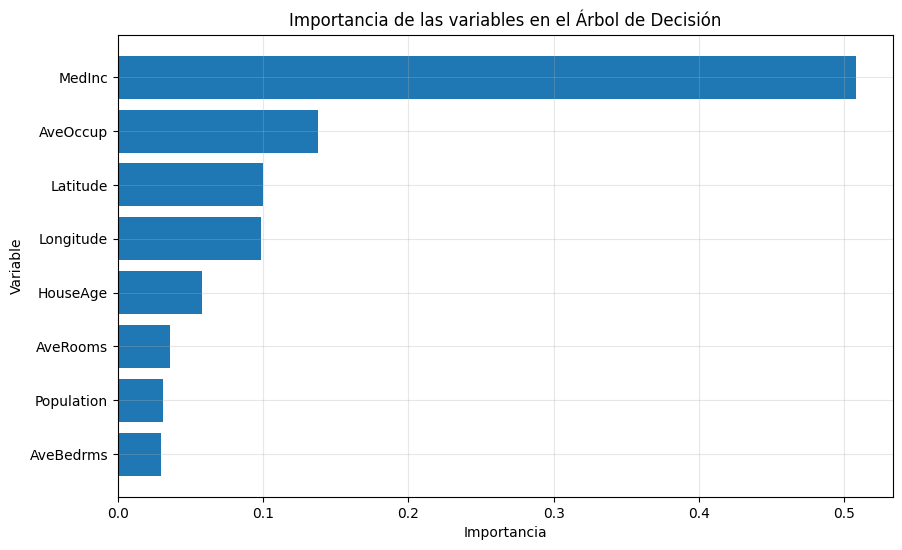

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importancia['Variable'],
    importancia['Importancia']
)

plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de las variables en el Árbol de Decisión')

plt.gca().invert_yaxis()

plt.grid(True, alpha=0.3)
plt.show()

### Interpretación

El análisis de importancia de variables muestra que **`MedInc`** es la característica con mayor influencia en el **Árbol de Decisión**, representando aproximadamente el **50,8 %** de la importancia total.

Le siguen **`AveOccup`**, **`Latitude`** y **`Longitude`**. En conjunto, estas cuatro variables concentran alrededor del **84,5 %** de la importancia del modelo.

Esto indica que el **ingreso medio del bloque**, la **ocupación promedio** y la **ubicación geográfica** son las variables que más contribuyen a las decisiones realizadas por el árbol para predecir **`MedHouseVal`**.

## Ahora se realiza el árbol de decisión con esas 4 variables

## Se realiza e mismo procedimiento que se utiliza en los árboles de decisión para realizarlo con las 4 variables con más importancia

In [43]:
X_reducido = datos[
    [
        'MedInc',
        'AveOccup',
        'Latitude',
        'Longitude'
    ]
].values

y = datos.iloc[:, 8].values

Se hace la separación de los datos 70% entrenamiento y 30% de prueba

In [44]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reducido,
    y,
    test_size=0.3,
    random_state=0
)

In [45]:
regressor_reducido = DecisionTreeRegressor(
    max_depth=11,
    min_samples_leaf=10,
    random_state=42
)

regressor_reducido.fit(
    X_train_red,
    y_train_red
);

Realizamos una comparación

In [46]:
y_pred_red = regressor_reducido.predict(X_test_red)

r2_red = regressor_reducido.score(
    X_test_red,
    y_test_red
)

rmse_red = np.sqrt(
    mean_squared_error(
        y_test_red,
        y_pred_red
    )
)

print("R²:", r2_red)
print(f"RMSE: ${rmse_red:,.0f}")

R²: 0.7536206943980208
RMSE: $57,481


## Gráfica del Árbol de Decisión con las 4 variables más importantes

Se visualiza el árbol entrenado con las cuatro variables que presentaron mayor importancia en el modelo inicial:

- `MedInc`
- `AveOccup`
- `Latitude`
- `Longitude`

Para mantener la gráfica legible se muestran únicamente los primeros niveles del árbol. Esto no modifica la profundidad real del modelo.

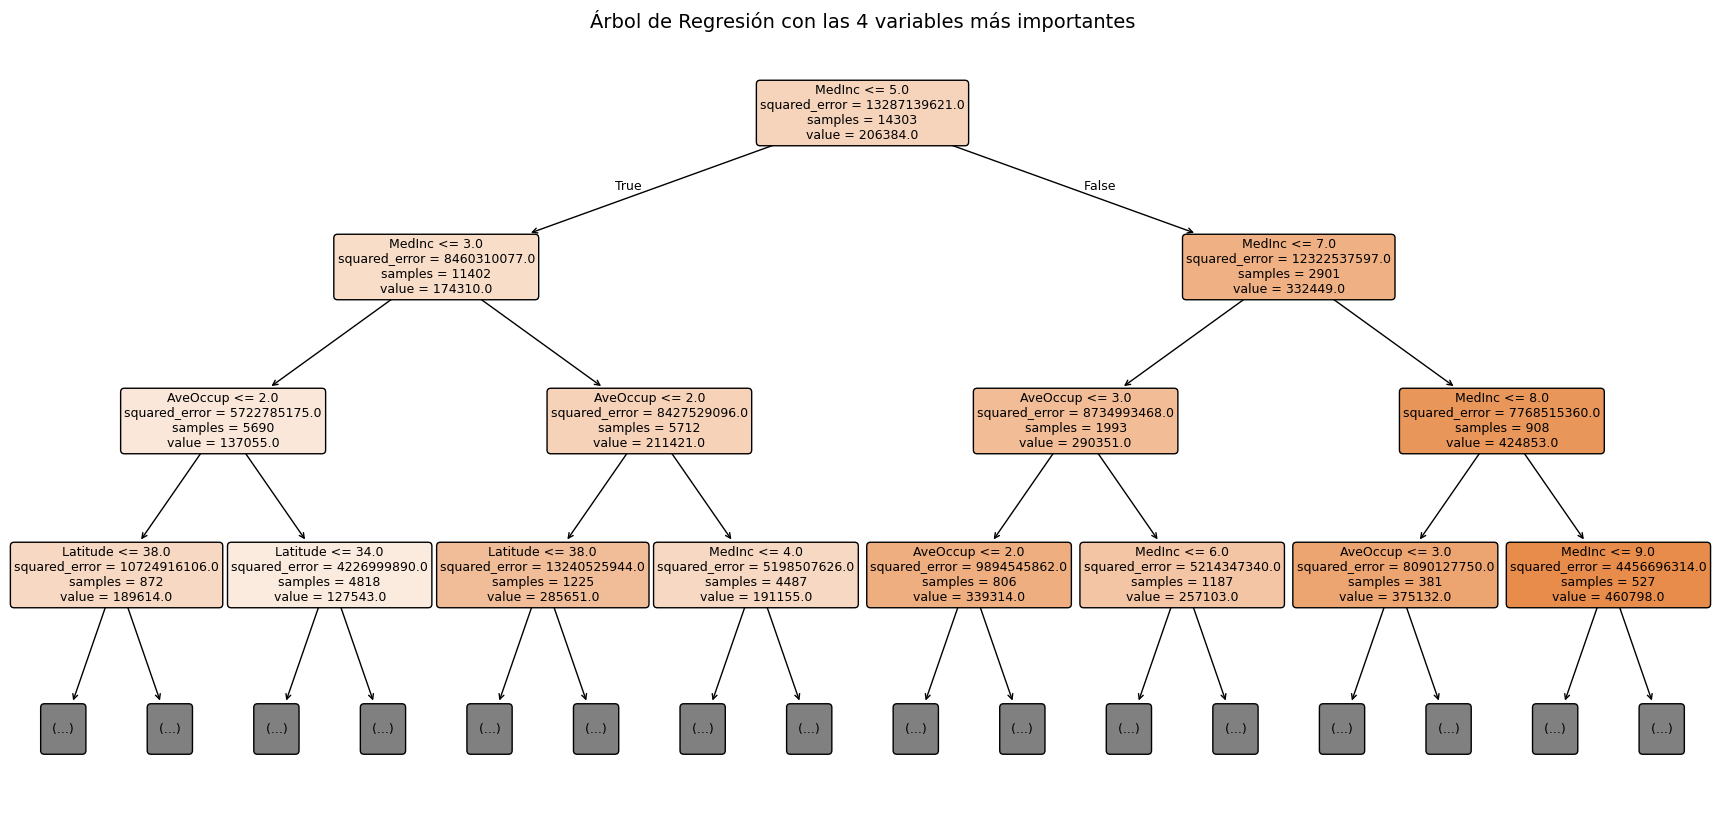

In [47]:
plt.figure(figsize=(22, 10))

plot_tree(
    regressor_reducido,
    feature_names=[
        'MedInc',
        'AveOccup',
        'Latitude',
        'Longitude'
    ],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    precision=0,
    max_depth=3
)

plt.title(
    'Árbol de Regresión con las 4 variables más importantes',
    fontsize=14
)

plt.savefig(
    'arbol_regresion_4_variables_importantes.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Comparación final: modelo de 8 variables vs. modelo de 4 variables

Para comparar los dos modelos se utilizan **los datos de prueba**, de modo que cada predicción se contraste con su valor real correspondiente.

Se calculan:

- **MSE (Mean Squared Error):** Error Cuadrático Medio.
- **RMSE (Root Mean Squared Error):** raíz del Error Cuadrático Medio. El RMSE queda expresado en las mismas unidades de `MedHouseVal`.

Un valor menor de **MSE** o **RMSE** indica un menor error de predicción.

In [48]:
# ============================================
# MODELO 1: Árbol con las 8 variables
# ============================================

y_pred_8 = regressor.predict(X_test)

mse_8 = mean_squared_error(
    y_test,
    y_pred_8
)

rmse_8 = np.sqrt(mse_8)


# ============================================
# MODELO 2: Árbol con las 4 variables
# ============================================

y_pred_4 = regressor_reducido.predict(X_test_red)

mse_4 = mean_squared_error(
    y_test_red,
    y_pred_4
)

rmse_4 = np.sqrt(mse_4)


# ============================================
# RESULTADOS
# ============================================

print("MODELO CON 8 VARIABLES")
print(f"MSE:  {mse_8:,.2f}")
print(f"RMSE: ${rmse_8:,.0f}")

print("\nMODELO CON 4 VARIABLES")
print(f"MSE:  {mse_4:,.2f}")
print(f"RMSE: ${rmse_4:,.0f}")

MODELO CON 8 VARIABLES
MSE:  5,615,215,727.16
RMSE: $74,935

MODELO CON 4 VARIABLES
MSE:  3,304,114,660.47
RMSE: $57,481


### Tabla comparativa

La siguiente tabla permite comparar directamente el error de los dos modelos.

In [49]:
comparacion_dos_modelos = pd.DataFrame({
    'Modelo': [
        'Árbol con 8 variables',
        'Árbol con 4 variables'
    ],
    'Número de variables': [8, 4],
    'MSE_Test': [mse_8, mse_4],
    'RMSE_Test': [rmse_8, rmse_4]
})

comparacion_dos_modelos

,Modelo,Número de variables,MSE_Test,RMSE_Test
0,Árbol con 8 variables,8,5.615216e+09,74934.743125
1,Árbol con 4 variables,4,3.304115e+09,57481.428831


### Comparación gráfica del RMSE

El modelo cuya barra sea más baja presenta un menor error de predicción sobre los datos de prueba.

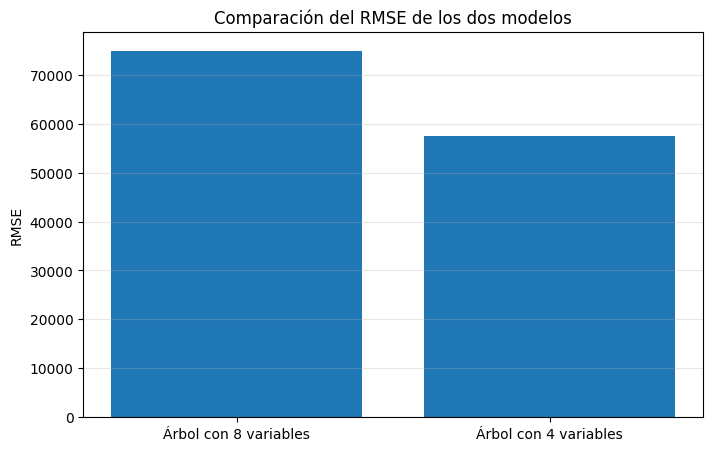

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparacion_dos_modelos['Modelo'],
    comparacion_dos_modelos['RMSE_Test']
)

plt.ylabel('RMSE')
plt.title('Comparación del RMSE de los dos modelos')
plt.grid(True, alpha=0.3, axis='y')

plt.show()

In [51]:
if rmse_8 < rmse_4:
    print(
        f"El modelo con 8 variables presenta el menor RMSE: "
        f"${rmse_8:,.0f}"
    )
elif rmse_4 < rmse_8:
    print(
        f"El modelo con 4 variables presenta el menor RMSE: "
        f"${rmse_4:,.0f}"
    )
else:
    print("Los dos modelos presentan el mismo RMSE.")

El modelo con 4 variables presenta el menor RMSE: $57,481


### Interpretación

El **RMSE** permite comparar el error promedio de predicción de ambos modelos en las mismas unidades de la variable objetivo. El modelo que obtenga el **RMSE más bajo** presenta, bajo esta evaluación, predicciones más cercanas a los valores reales del conjunto de prueba.

> **Nota metodológica:** en este notebook los dos modelos no tienen exactamente la misma configuración. El árbol de 8 variables fue entrenado sin limitar su profundidad, mientras que el árbol de 4 variables utiliza `max_depth=11` y `min_samples_leaf=10`. Por lo tanto, la diferencia observada entre sus errores puede estar relacionada tanto con la reducción de variables como con el control de la complejidad del segundo árbol.

### ¿Por qué limitar la profundidad del árbol?

Limitar la profundidad permite controlar la complejidad del Árbol de Decisión y reducir el riesgo de **sobreajuste**.

Un árbol sin restricciones puede generar muchas divisiones hasta ajustarse casi perfectamente a los datos de entrenamiento. Aunque esto puede producir un R² muy alto en entrenamiento, el modelo puede presentar un peor desempeño cuando realiza predicciones sobre datos nuevos.

El parámetro `max_depth` limita el número máximo de niveles que puede alcanzar el árbol, mientras que `min_samples_leaf` establece el número mínimo de observaciones que debe contener una hoja final.

Estas restricciones permiten construir un modelo más simple y con mayor capacidad de generalización.